In [104]:
import pandas as pd

In [105]:
df = pd.read_csv(r"C:\Users\Admin\Desktop\DL DATA\Autism-Adult-Data.csv")
df

,1,1.1,1.2,1.3,0,0.1,1.4,1.5,0.2,0.3,...,f,White-European,no,no.1,'United States',no.2,6,'18 and more',Self,NO
0,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
1,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
2,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
3,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2,'18 and more',?,NO
4,1,1,1,1,1,0,1,1,1,1,...,m,Others,yes,no,'United States',no,9,'18 and more',Self,YES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
698,0,1,0,1,1,0,1,1,1,1,...,f,White-European,no,no,Russia,no,7,'18 and more',Self,YES
699,1,0,0,0,0,0,0,1,0,1,...,m,Hispanic,no,no,Mexico,no,3,'18 and more',Parent,NO
700,1,0,1,1,1,0,1,1,0,1,...,f,?,no,no,Russia,no,7,'18 and more',?,YES
701,1,0,0,1,1,0,1,0,1,1,...,m,'South Asian',no,no,Pakistan,no,6,'18 and more',Self,NO


In [106]:

df = pd.read_csv(r"C:\Users\Admin\Desktop\DL DATA\Autism-Adult-Data.csv", header=None)
#
columns = [
    "A1","A2","A3","A4","A5","A6","A7","A8","A9","A10",
    "age","gender","ethnicity","jundice","austim",
    "country","used_app_before","result","age_desc",
    "relation","Class"
]

df.columns = columns
df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,gender,ethnicity,jundice,austim,country,used_app_before,result,age_desc,relation,Class
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,'United States',no,6,'18 and more',Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,'18 and more',Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,'18 and more',Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,'United States',no,6,'18 and more',Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2,'18 and more',?,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,0,1,0,1,1,0,1,1,1,1,...,f,White-European,no,no,Russia,no,7,'18 and more',Self,YES
700,1,0,0,0,0,0,0,1,0,1,...,m,Hispanic,no,no,Mexico,no,3,'18 and more',Parent,NO
701,1,0,1,1,1,0,1,1,0,1,...,f,?,no,no,Russia,no,7,'18 and more',?,YES
702,1,0,0,1,1,0,1,0,1,1,...,m,'South Asian',no,no,Pakistan,no,6,'18 and more',Self,NO


##data cleaning

In [107]:
df.replace('?', pd.NA, inplace=True) # استبدال القيم الغلط

In [108]:
df.isnull().sum()

A1                  0
A2                  0
A3                  0
A4                  0
A5                  0
A6                  0
A7                  0
A8                  0
A9                  0
A10                 0
age                 2
gender              0
ethnicity          95
jundice             0
austim              0
country             0
used_app_before     0
result              0
age_desc            0
relation           95
Class               0
dtype: int64

In [109]:
df.dropna(inplace=True)  # حذف القيم الناقصة


In [110]:
df.drop_duplicates(inplace=True)

In [111]:
X = df.drop("Class", axis=1)
y = df["Class"]

##تحويل الـ Target لأرقام

In [112]:
from sklearn.preprocessing import LabelEncoder

In [113]:


le = LabelEncoder()
y = le.fit_transform(y)  # YES=1, NO=0

##تحويل البيانات النصية (Encoding)

In [114]:
from sklearn.preprocessing import OrdinalEncoder

In [115]:
cat_cols = X.select_dtypes(include=['object']).columns

encoder = OrdinalEncoder()

X[cat_cols] = encoder.fit_transform(X[cat_cols])

##visualization

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt


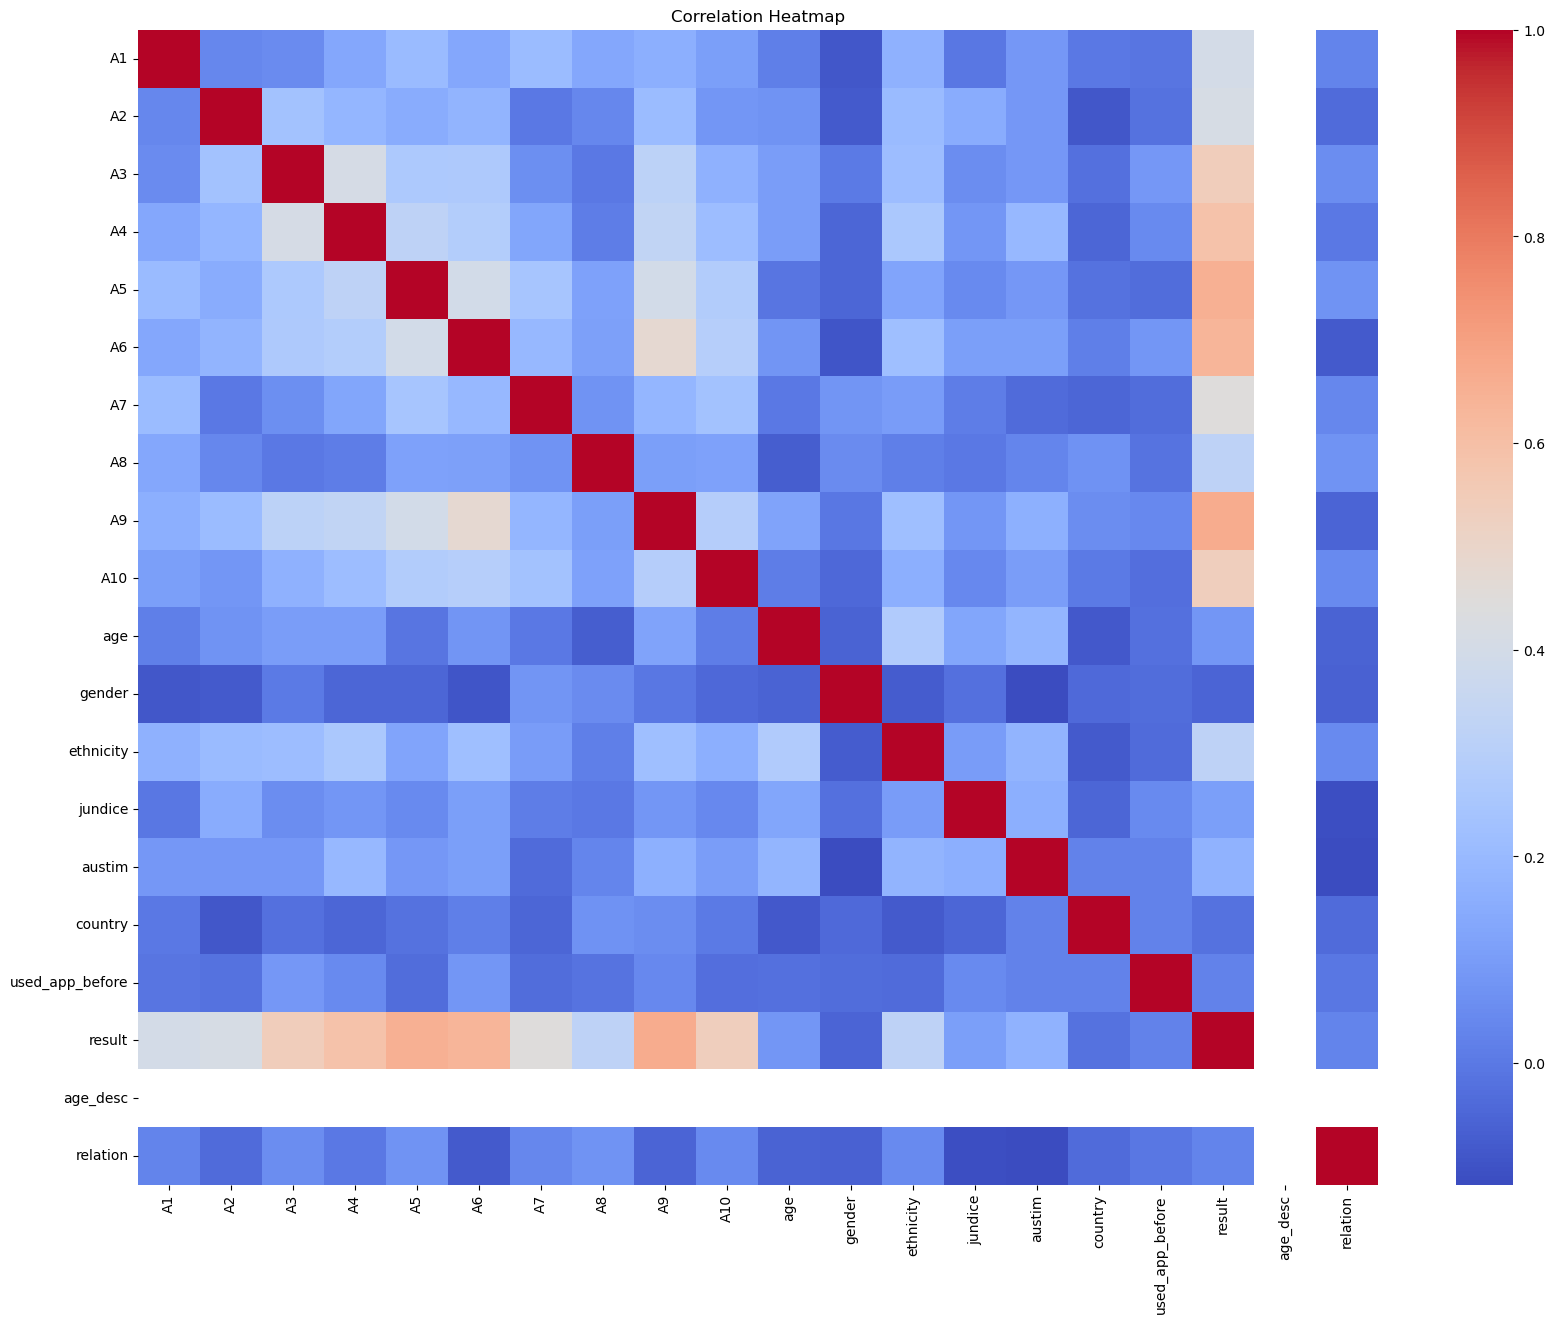

In [117]:
plt.figure(figsize=(20,15))
sns.heatmap(X.corr(numeric_only=True), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

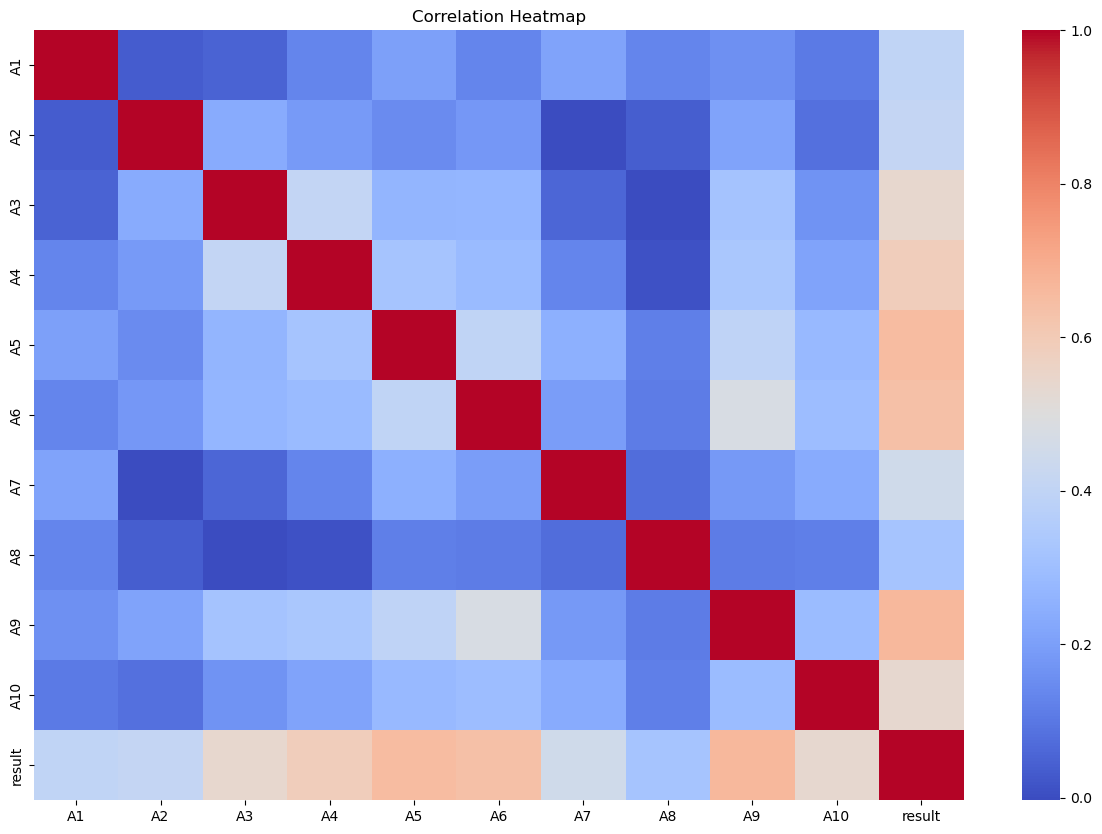

In [118]:

plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

##splitting data

In [119]:
from sklearn.model_selection import train_test_split

In [120]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##Scaling

In [121]:
from sklearn.preprocessing import StandardScaler

In [122]:

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##Deep Learning model

In [123]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


In [135]:

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),                #prevent overfitting

    Dense(32, activation='relu'),  # learn more details
    Dropout(0.3),

    Dense(16, activation='relu'),   #concentrate the important feature 

    Dense(1, activation='sigmoid')   #output between 0,1
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,969 (15.50 KB)

 Trainable params: 3,969 (15.50 KB)

 Non-trainable params: 0 (0.00 B)

##Compile

In [125]:
model.compile(
    optimizer='adam',            # the best optimizer for model
    loss='binary_crossentropy',  #suitable for Binary Classification
    metrics=['accuracy']
)

##Early Stopping

In [126]:
from tensorflow.keras.callbacks import EarlyStopping


In [127]:

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

##model training

In [128]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6198 - loss: 0.6546 - val_accuracy: 0.9184 - val_loss: 0.5679
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8502 - loss: 0.5206 - val_accuracy: 1.0000 - val_loss: 0.4372
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8871 - loss: 0.4065 - val_accuracy: 1.0000 - val_loss: 0.3162
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9171 - loss: 0.3098 - val_accuracy: 1.0000 - val_loss: 0.2162
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9217 - loss: 0.2371 - val_accuracy: 1.0000 - val_loss: 0.1578
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9424 - loss: 0.1791 - val_accuracy: 1.0000 - val_loss: 0.1167
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9677 - loss: 0.1360 - val_accuracy: 1.0000 - val_loss: 0.0860
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9700 - loss: 0.1091 - val_accuracy: 1.0000 - val_loss:

##evaluate model

In [129]:
loss, acc = model.evaluate(X_test, y_test)

print("Accuracy:", acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9835 - loss: 0.0532 
Accuracy: 0.9834710955619812


##visualization result

In [130]:
import matplotlib.pyplot as plt


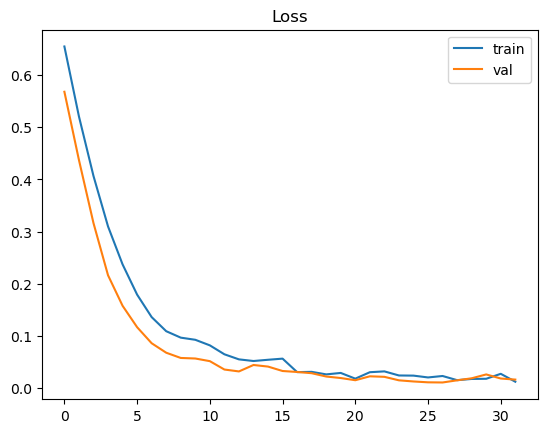

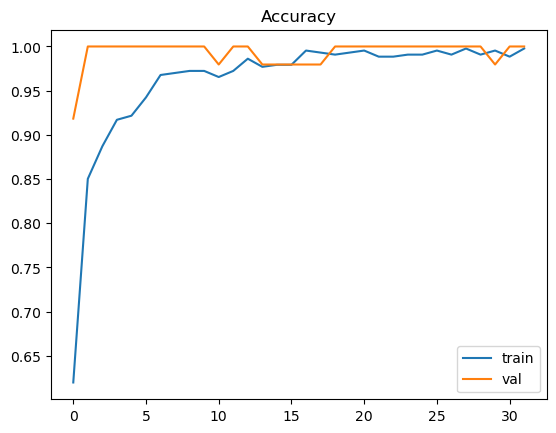

In [131]:

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['train', 'val'])
plt.show()

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['train', 'val'])
plt.show()

In [132]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000027097C4ECA0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        75
           1       0.96      1.00      0.98        46

    accuracy                      

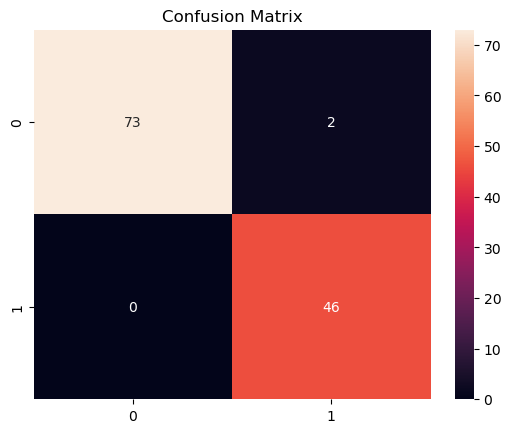

In [133]:


y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()